## 4. Evaluation

### 4.1 Importing the Library

In [19]:
import pickle
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [20]:
DATA_DIR = "../dataset/processed/02_after_FE"
MODEL_DIR = "../models"

### 4.2 Load the Data

In [21]:
X_test_tfidf  = pickle.load(open(os.path.join(DATA_DIR, "X_test_tfidf.pkl"), "rb"))
X_test_pad    = pickle.load(open(os.path.join(DATA_DIR, "X_test_pad.pkl"), "rb"))
y_test        = pickle.load(open(os.path.join(DATA_DIR, "y_test.pkl"), "rb"))

y_test = np.array(y_test)

### 4.3 Check Array Dimension

In [22]:
X_test_pad = np.array(X_test_pad, dtype='int32')
y_test_sklearn = y_test.astype(int).ravel()

### 4.4 Load Models

In [23]:
rf_model     = pickle.load(open(os.path.join(MODEL_DIR, "rf_model.pkl"), "rb"))
lstm_model   = load_model(os.path.join(MODEL_DIR, "lstm_model.keras"))
bilstm_model = load_model(os.path.join(MODEL_DIR, "bilstm_model.keras"))

/home/calista/anaconda3/envs/dl/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/calista/anaconda3/envs/dl/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### 4.5 Evaluating Function

In [24]:
def evaluate_model_metrics(y_true, y_pred_binary, y_pred_proba):
    """Menghitung semua metrik, termasuk ROC-AUC."""
    
    acc = accuracy_score(y_true, y_pred_binary)
    prec = precision_score(y_true, y_pred_binary, zero_division=0, pos_label=1)
    rec = recall_score(y_true, y_pred_binary, zero_division=0, pos_label=1)
    f1 = f1_score(y_true, y_pred_binary, zero_division=0, pos_label=1)
    
    auc = roc_auc_score(y_true, y_pred_proba)

    return {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1
    }

def round_metrics(metrics_dict):
    return {k: round(v, 4) for k, v in metrics_dict.items()}

### 4.6 Predicting and Evaluate All Models

In [25]:
scores = {}

rf_pred_proba = rf_model.predict_proba(X_test_tfidf)[:, 1] 
rf_pred_binary = rf_model.predict(X_test_tfidf) 
scores['Random Forest'] = round_metrics(
    evaluate_model_metrics(y_test_sklearn, rf_pred_binary, rf_pred_proba)
)

lstm_pred_proba = lstm_model.predict([X_test_pad, X_test_tfidf], verbose=0).flatten() 
lstm_pred_binary = (lstm_pred_proba > 0.5).astype(int)
scores['LSTM + TF-IDF'] = round_metrics(
    evaluate_model_metrics(y_test_sklearn, lstm_pred_binary, lstm_pred_proba)
)

bilstm_pred_proba = bilstm_model.predict([X_test_pad, X_test_tfidf], verbose=0).flatten()
bilstm_pred_binary = (bilstm_pred_proba > 0.5).astype(int)
scores['BiLSTM + TF-IDF'] = round_metrics(
    evaluate_model_metrics(y_test_sklearn, bilstm_pred_binary, bilstm_pred_proba)
)


for model_name, metrics in scores.items():
    print(f"\n-{model_name}-")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value}")

[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished



-Random Forest-
accuracy: 0.9732
precision: 0.7772
recall: 0.9202
f1: 0.8427

-LSTM + TF-IDF-
accuracy: 0.9816
precision: 0.8673
recall: 0.9018
f1: 0.8842

-BiLSTM + TF-IDF-
accuracy: 0.9811
precision: 0.8921
recall: 0.862
f1: 0.8768


In [26]:
results_df = pd.DataFrame(scores).T 

results_df = results_df.rename_axis('Model')
results_df = results_df.reset_index() 

print("--- Comparison ---")
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))

--- Comparison ---
| Model           | accuracy   | precision   | recall   | f1     |
|:----------------|:-----------|:------------|:---------|:-------|
| Random Forest   | 0.9732     | 0.7772      | 0.9202   | 0.8427 |
| LSTM + TF-IDF   | 0.9816     | 0.8673      | 0.9018   | 0.8842 |
| BiLSTM + TF-IDF | 0.9811     | 0.8921      | 0.862    | 0.8768 |


### 4.7 Visualizing

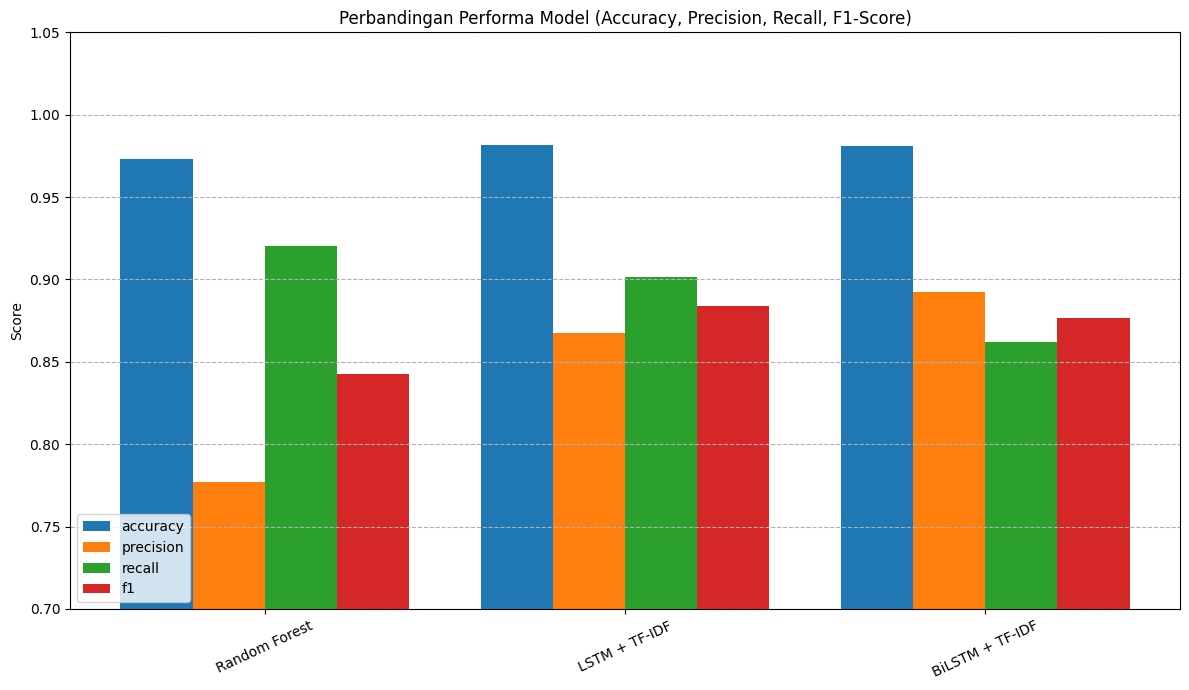

In [27]:
models = list(scores.keys())
metrics = ["accuracy", "precision", "recall", "f1"]

values = np.array([[scores[m][metric] for metric in metrics] for m in models])

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 7)) 

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, values[:, i], width, label=metric)

plt.xticks(x + width * 1.5, models, rotation=25) 
plt.ylabel("Score")
plt.ylim(0.70, 1.05)
plt.title("Perbandingan Performa Model (Accuracy, Precision, Recall, F1-Score)")
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# %%